In [ ]:
#@title Setup
import datetime
import glob
import json
import pandas as pd
import os
from IPython.display import Image
from ysngs import Config, WorkFlow, execCmd, curlDownload
yscfg = Config()
yscfg.setEnvs()
from ysngs.prepare import preparInput

In [ ]:
#@title Select WDL script
prefix = 'dlfq' #@param {"type": "string"}
wdl = f'{prefix}.wdl'
script = os.path.join(os.environ['HYM_SCRIPT'], 'wdl', wdl)
## Make workflow instance
wf = WorkFlow(script)
wf.check()

Success!


In [ ]:
#@title Make input(s) for downloading sequence data
# Set input
list_file = 'Sample/list.txt'  #@param {type: 'string'}
data_ids = ''  #@param {type: 'string'}
out_dir = 'Sample' #@param {type: 'string'}
thread = 16 #@param {type: 'raw'}
## Prepare input 
input_path = preparInput(prefix, {
    'ids': data_ids.split(',') if data_ids != '' else [],
    'list': list_file,
    'out_dir': os.path.join(os.environ['HYM_DATA'], out_dir)
    'thread': thread
})

['SRR32007584', 'SRR32007585', 'SRR32007586', 'SRR12060749', 'SRR12060750', 'SRR12060760', 'SRR12060761', 'SRR12060764', 'SRR12060775', 'SRR12060776', 'SRR12060810', 'SRR12060811']


In [ ]:
#@title Run (Use SRA toolkit)
inputs = json.load(open(input_path))
for input in inputs:
    now = datetime.datetime.now()
    path = os.path.join(os.environ['HYM_TEMP'], f"{now.strftime('%Y-%m-%d_%H-%M-%S')}.json")
    json.dump(input, open(path, 'w'))
    # Run
    wf.run(path)

Success!
Run: > java -jar $HYM_APP/cromwell.jar run --inputs /media/phys2/ionDataArchive/Temp/2025-09-26_10-05-35.json /media/phys2/ionDataArchive/Script/wdl/dlfq.wdl
[2025-09-26 10:05:38,81] [info] Running with database db.url = jdbc:hsqldb:mem:60d0d632-ff9b-4d54-b650-c6ff002f6c08;shutdown=false;hsqldb.tx=mvcc
[2025-09-26 10:05:41,56] [info] Running migration RenameWorkflowOptionsInMetadata with a read batch size of 100000 and a write batch size of 100000
[2025-09-26 10:05:41,57] [info] [RenameWorkflowOptionsInMetadata] 100%
[2025-09-26 10:05:41,83] [info] Running with database db.url = jdbc:hsqldb:mem:913919ab-0878-4bd0-8a01-bf3c7fbd3955;shutdown=false;hsqldb.tx=mvcc
[2025-09-26 10:05:42,51] [info] Slf4jLogger started
[2025-09-26 10:05:43,12] [info] Workflow heartbeat configuration:
{
"cromwellId" : "cromid-d747fc8",
"heartbeatInterval" : "2 minutes",
"ttl" : "10 minutes",
"failureShutdownDuration" : "5 minutes",
"writeBatchSize" : 10000,
"writeThreshold" : 10000
}
[2025-09-26 10:05:

Run: > java -jar $HYM_APP/womtool.jar womgraph /media/phys2/ionDataArchive/Script/wdl/dlfq.wdl > /media/phys2/ionDataArchive/Log/dlfq.dot
Run: > dot -Tpng /media/phys2/ionDataArchive/Log/dlfq.dot > /media/phys2/ionDataArchive/Log/dlfq.png
Workflow image was exported to '/media/phys2/ionDataArchive/Log/dlfq.png'


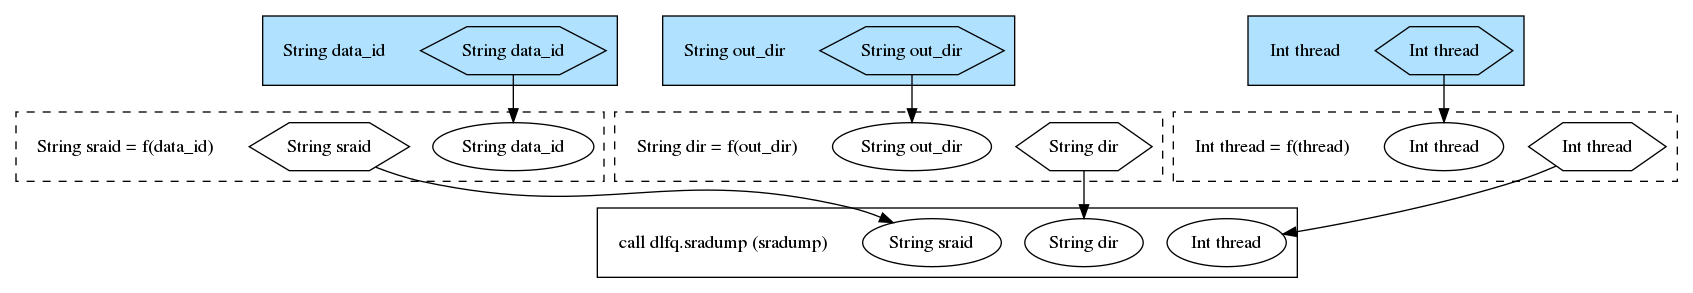

In [8]:
#@title Visualize
## Set image file path
graph_path = os.path.join(os.environ['HYM_LOG'], f"{os.path.split(wf.script)[1].replace('.wdl', '.dot')}")
img_path = graph_path.replace('.dot', '.png')
## Make dot file
wf.graph(graph_path, detailed=True)
## Display
display(Image(img_path))